# 2. Análisis exploratorio de datos (EDA)

Todo el análisis de este capítulo usa únicamente el conjunto de entrenamiento (44 903 adultos),
reservado en la sección 1.7. El conjunto de prueba no se abre hasta la evaluación final del modelo
base.

Dado el tamaño de la muestra, casi cualquier diferencia resulta estadísticamente significativa, así
que cada prueba se acompaña de un tamaño de efecto y, cuando se hacen muchas pruebas a la vez, los
valores p se corrigen por comparaciones múltiples con el método de Holm.


In [1]:
import sys, warnings
from pathlib import Path
RAIZ = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(RAIZ))
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, Markdown

from src.utils import *

estilo_graficos()
np.random.seed(SEED)
pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 180)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

from scipy import stats
from statsmodels.stats.multitest import multipletests
from statsmodels.stats.proportion import proportion_confint

train, _ = cargar_particiones()
y = train[OBJETIVO]
print(f"Conjunto de entrenamiento: {train.shape[0]:,} filas")

def dummies_referencia(df):
    # One-hot con la misma categoría de referencia que usará el modelo
    out = df.copy()
    for v in PREDICTORAS_CAT:
        orden = CATEGORIAS.get(v) or ORDENES.get(v)
        if v == "imc_categoria":
            orden = ["Normal", "Bajo peso", "Sobrepeso", "Obesidad"]
        out[v] = pd.Categorical(out[v], categories=orden)
    return pd.get_dummies(out[PREDICTORAS_CAT], drop_first=True, dtype=float)

def prev_ic(serie_y):
    k, n = serie_y.sum(), serie_y.count()
    li, ls = proportion_confint(k, n, method="wilson")
    return pd.Series({"n": n, "prevalencia": k / n, "ic_inf": li, "ic_sup": ls})

Conjunto de entrenamiento: 44,903 filas


## 2.1 Análisis de la variable objetivo

La pregunta original tiene cuatro niveles. Se dicotomiza en 0 para sin dificultad y 1 para alguna
dificultad, mucha dificultad o no puede, porque los niveles superiores son demasiado escasos para
modelarlos por separado y porque la literatura sobre queja cognitiva subjetiva considera relevante
cualquier nivel de dificultad percibida.


,n,proporción
nivel_dificultad_cognitiva,,
Ninguna,"35,650",79.39%
Alguna,"8,236",18.34%
Mucha,"1,002",2.23%
No puede,15,0.03%


Clase 0 (sin dificultad): 35,650 | Clase 1 (con dificultad): 9,253
Prevalencia: 20.61% | Razón de desbalance 0:1 = 3.85 : 1 | Casos de la clase minoritaria: 9,253


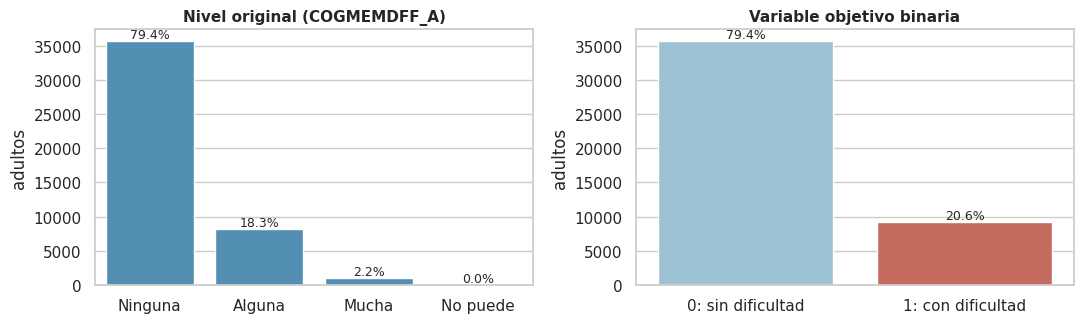

In [2]:
nivel = train["nivel_dificultad_cognitiva"].value_counts().reindex(ORDENES["nivel_dificultad_cognitiva"])
tabla_obj = pd.DataFrame({"n": nivel, "proporción": nivel / nivel.sum()})
display(tabla_obj.style.format({"n": "{:,}", "proporción": "{:.2%}"}))

binaria = y.value_counts().sort_index()
ratio = binaria[0] / binaria[1]
print(f"Clase 0 (sin dificultad): {binaria[0]:,} | Clase 1 (con dificultad): {binaria[1]:,}")
print(f"Prevalencia: {y.mean():.2%} | Razón de desbalance 0:1 = {ratio:.2f} : 1 | Casos de la clase minoritaria: {binaria[1]:,}")

fig, axes = plt.subplots(1, 2, figsize=(11, 3.4))
sns.barplot(x=nivel.index, y=nivel.values, ax=axes[0], color="#4393c3")
axes[0].set_title("Nivel original (COGMEMDFF_A)"); axes[0].set_xlabel(""); axes[0].set_ylabel("adultos")
for i, v in enumerate(nivel.values):
    axes[0].text(i, v, f"{v / nivel.sum():.1%}", ha="center", va="bottom", fontsize=9)
sns.barplot(x=["0: sin dificultad", "1: con dificultad"], y=binaria.values, ax=axes[1],
            palette=["#92c5de", "#d6604d"])
axes[1].set_title("Variable objetivo binaria"); axes[1].set_ylabel("adultos")
for i, v in enumerate(binaria.values):
    axes[1].text(i, v, f"{v / binaria.sum():.1%}", ha="center", va="bottom", fontsize=9)
plt.tight_layout(); plt.show()

,n,prevalencia,ic_inf,ic_sup
anio,,,,
2022,"21,722",20.42%,19.89%,20.96%
2023,"23,181",20.78%,20.26%,21.31%


Año: chi2 = 0.86, p = 0.354, V de Cramér = 0.000
Trimestre (8 periodos): chi2 = 16.21, p = 0.023, V de Cramér = 0.014


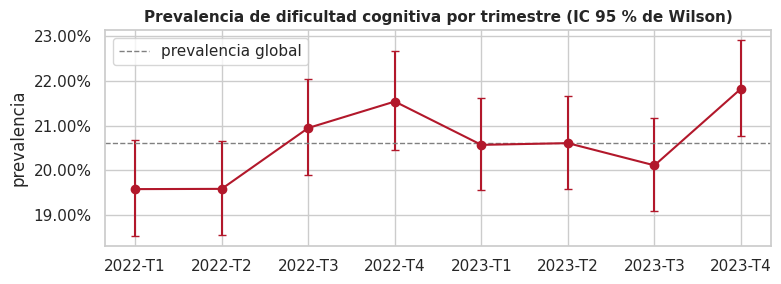

In [3]:
# Comportamiento de la variable objetivo en el tiempo (año y trimestre de entrevista)
por_anio = train.groupby("anio")[OBJETIVO].apply(prev_ic).unstack()
por_trim = train.groupby(["anio", "trimestre"])[OBJETIVO].apply(prev_ic).unstack()
display(por_anio.style.format({"n": "{:,.0f}", "prevalencia": "{:.2%}", "ic_inf": "{:.2%}", "ic_sup": "{:.2%}"}))

t_anio = pd.crosstab(train["anio"], y)
chi_a, p_a, _, _ = stats.chi2_contingency(t_anio)
t_trim = pd.crosstab(train["anio"].astype(str) + "-T" + train["trimestre"].astype(str), y)
chi_t, p_t, _, _ = stats.chi2_contingency(t_trim)
print(f"Año: chi2 = {chi_a:.2f}, p = {p_a:.3f}, V de Cramér = {cramers_v(t_anio):.3f}")
print(f"Trimestre (8 periodos): chi2 = {chi_t:.2f}, p = {p_t:.3f}, V de Cramér = {cramers_v(t_trim):.3f}")

fig, ax = plt.subplots(figsize=(8, 3))
etiquetas = [f"{a}-T{t}" for a, t in por_trim.index]
ax.errorbar(etiquetas, por_trim["prevalencia"], yerr=[por_trim["prevalencia"] - por_trim["ic_inf"],
            por_trim["ic_sup"] - por_trim["prevalencia"]], fmt="o-", capsize=3, color="#b2182b")
ax.axhline(y.mean(), ls="--", color="gray", lw=1, label="prevalencia global")
ax.set_ylabel("prevalencia"); ax.set_title("Prevalencia de dificultad cognitiva por trimestre (IC 95 % de Wilson)")
ax.yaxis.set_major_formatter(plt.matplotlib.ticker.PercentFormatter(1)); ax.legend()
plt.tight_layout(); plt.show()

En entrenamiento, el 20,6 % de los adultos reporta algún grado de dificultad para recordar o
concentrarse, unos 9 253 casos. Casi todos esos casos corresponden al nivel de alguna dificultad
(18,3 %); mucha dificultad es el 2,2 % y no puede es apenas el 0,03 %, solo 15 personas, lo que
confirma que modelar los cuatro niveles por separado no sería viable y justifica la dicotomización.

Hay un desbalance moderado, de 3,85 a 1. No es extremo, pero alcanza para que el accuracy resulte
engañoso: un modelo que siempre prediga sin dificultad acertaría el 79,4 % de las veces. Por eso las
métricas principales van a ser la PR-AUC, cuya referencia trivial es la prevalencia (0,206), el
ROC-AUC, el recall, la precisión y el F1 de la clase positiva, y tanto la partición como la
validación cruzada serán estratificadas.

En cuanto a la estabilidad en el tiempo, la prevalencia es prácticamente igual en 2022 (20,4 %) y en
2023 (20,8 %), con p = 0,35 y V de Cramér cercano a 0. Entre trimestres aparece una diferencia
estadísticamente significativa (p = 0,023), pero con un tamaño de efecto despreciable (V = 0,014) y
sin ninguna tendencia clara: todos los intervalos se superponen con la prevalencia global. No hay
evidencia de deriva, así que combinar los dos años es válido y no se necesita una validación
cronológica.


## 2.2 Análisis unidimensional

### 2.2.1 Variables numéricas

La única predictora numérica es la edad. El IMC numérico se analiza como apoyo del EDA, aunque no
entra al modelo (ver 1.9.2).


In [4]:
num = train[["edad", "imc"]]
desc = num.describe(percentiles=[0.05, 0.25, 0.5, 0.75, 0.95]).T
desc["asimetría"] = num.skew()
desc["curtosis (exceso)"] = num.kurt()
desc["CV"] = desc["std"] / desc["mean"]
display(desc.style.format("{:.2f}").format({"count": "{:,.0f}"}))

for var in ["edad", "imc"]:
    x = num[var].dropna()
    k2, p = stats.normaltest(x)
    x_m = x.sample(500, random_state=SEED)
    w, p_w = stats.shapiro(x_m)
    print(f"{var}: D'Agostino-Pearson K² = {k2:,.0f} (p = {p:.1e}); Shapiro-Wilk en submuestra de 500: W = {w:.3f} (p = {p_w:.1e})")

,count,mean,std,min,5%,25%,50%,75%,95%,max,asimetría,curtosis (exceso),CV
edad,"44,797",52.863473,18.402537,18.000000,23.000000,37.000000,54.000000,68.000000,82.000000,85.000000,-0.066601,-1.107622,0.348114
imc,"41,099",27.996269,5.520933,14.770000,20.360000,23.910000,27.320000,31.240000,38.390000,53.720000,0.710363,0.364166,0.197202


edad: D'Agostino-Pearson K² = 19,464 (p = 0.0e+00); Shapiro-Wilk en submuestra de 500: W = 0.961 (p = 3.7e-10)
imc: D'Agostino-Pearson K² = 2,990 (p = 0.0e+00); Shapiro-Wilk en submuestra de 500: W = 0.965 (p = 1.8e-09)


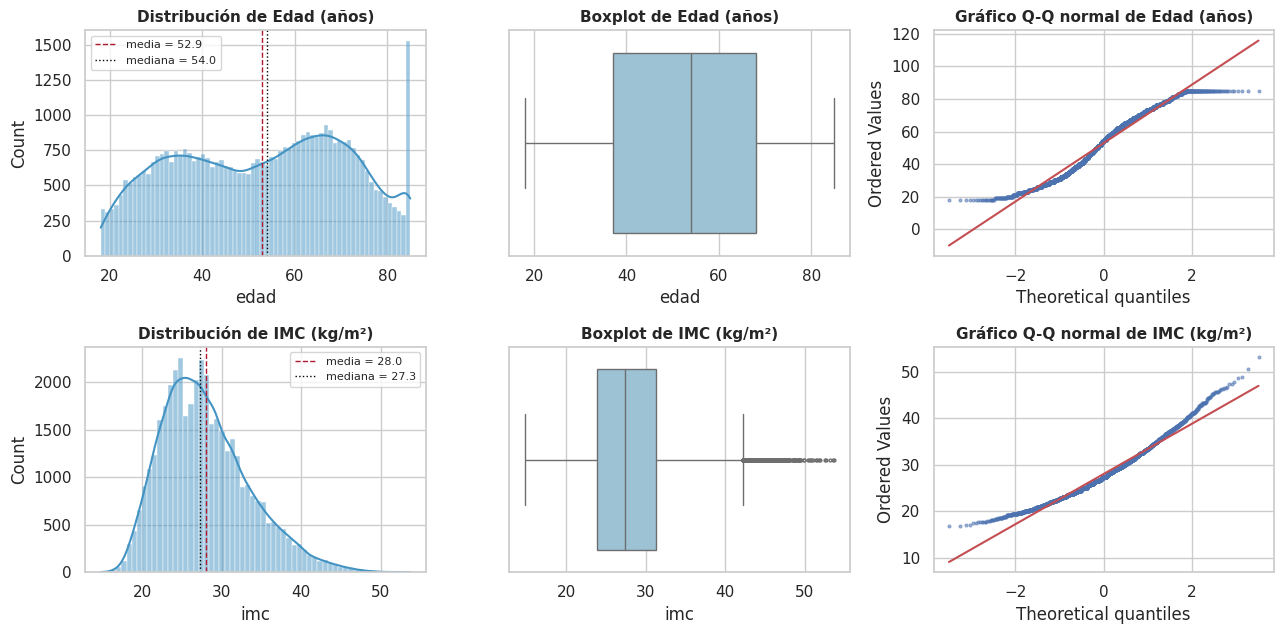

In [5]:
fig, axes = plt.subplots(2, 3, figsize=(13, 6.5))
for fila, (var, etiqueta) in enumerate([("edad", "Edad (años)"), ("imc", "IMC (kg/m²)")]):
    x = num[var].dropna()
    sns.histplot(x, bins=68 if var == "edad" else 60, kde=True, ax=axes[fila, 0], color="#4393c3")
    axes[fila, 0].axvline(x.mean(), color="#b2182b", ls="--", lw=1, label=f"media = {x.mean():.1f}")
    axes[fila, 0].axvline(x.median(), color="black", ls=":", lw=1, label=f"mediana = {x.median():.1f}")
    axes[fila, 0].legend(fontsize=8); axes[fila, 0].set_title(f"Distribución de {etiqueta}")
    sns.boxplot(x=x, ax=axes[fila, 1], color="#92c5de", fliersize=2)
    axes[fila, 1].set_title(f"Boxplot de {etiqueta}")
    stats.probplot(x.sample(3000, random_state=SEED), dist="norm", plot=axes[fila, 2])
    axes[fila, 2].set_title(f"Gráfico Q-Q normal de {etiqueta}")
    axes[fila, 2].get_lines()[0].set(markersize=2, alpha=0.5)
plt.tight_layout(); plt.show()

La edad tiene una media de 52,9 años y una mediana de 54, con un rango de 18 a 85. Su distribución
es casi simétrica (asimetría de -0,07) pero platicúrtica, con una curtosis de -1,11: es
aproximadamente uniforme entre los 25 y los 80 años, con un pico artificial en 85 por el
truncamiento. No es normal, todas las pruebas la rechazan, incluso Shapiro-Wilk en una submuestra de
500, lo que muestra que el rechazo no se debe solo al tamaño de la muestra. Esto no es un problema
para una regresión logística, que no exige normalidad en las predictoras, aunque sí refuerza la
decisión de escalarla dentro del pipeline.

El IMC tiene una media de 28,0 kg/m², es decir sobrepeso en promedio, con asimetría positiva (0,71)
y una cola hacia la obesidad severa. Su distribución tampoco es normal, y además está recortada en
los extremos por la supresión del NCHS (ver 1.9.2). Como el IMC numérico no entra al modelo, no se
transforma.


### 2.2.2 Variables categóricas

In [6]:
filas = []
for v in PREDICTORAS_CAT:
    vc = train[v].value_counts(normalize=True)
    raras = vc[vc < 0.01]
    filas.append([v, DICCIONARIO.set_index("variable").loc[v, "tipo"], train[v].nunique(), vc.index[0], vc.iloc[0],
                  ", ".join(f"{c} ({p:.2%})" for c, p in raras.items()) or "—"])
resumen_cat = pd.DataFrame(filas, columns=["variable", "tipo", "cardinalidad", "moda", "% moda",
                                           "categorías raras (< 1 %)"])
display(resumen_cat.style.hide(axis="index").format({"% moda": "{:.1%}"}))

variable,tipo,cardinalidad,moda,% moda,categorías raras (< 1 %)
sexo,Nominal binaria,2,Mujer,54.5%,—
raza_etnia,Nominal (7),7,Blanco no hispano,66.1%,"AIAN y otro grupo (0.70%), AIAN no hispano (0.67%)"
educacion,Ordinal (5),5,Técnico o universidad incompleta,28.0%,—
hipertension,Binaria,2,No,62.9%,—
colesterol_alto,Binaria,2,No,68.0%,—
diabetes,Binaria,2,No,89.2%,—
acv,Binaria,2,No,96.5%,—
depresion_dx,Binaria,2,No,81.0%,—
frecuencia_depresion,Ordinal (5),5,Nunca,52.6%,—
dificultad_auditiva,Ordinal (4),4,Ninguna,82.7%,No puede (0.07%)


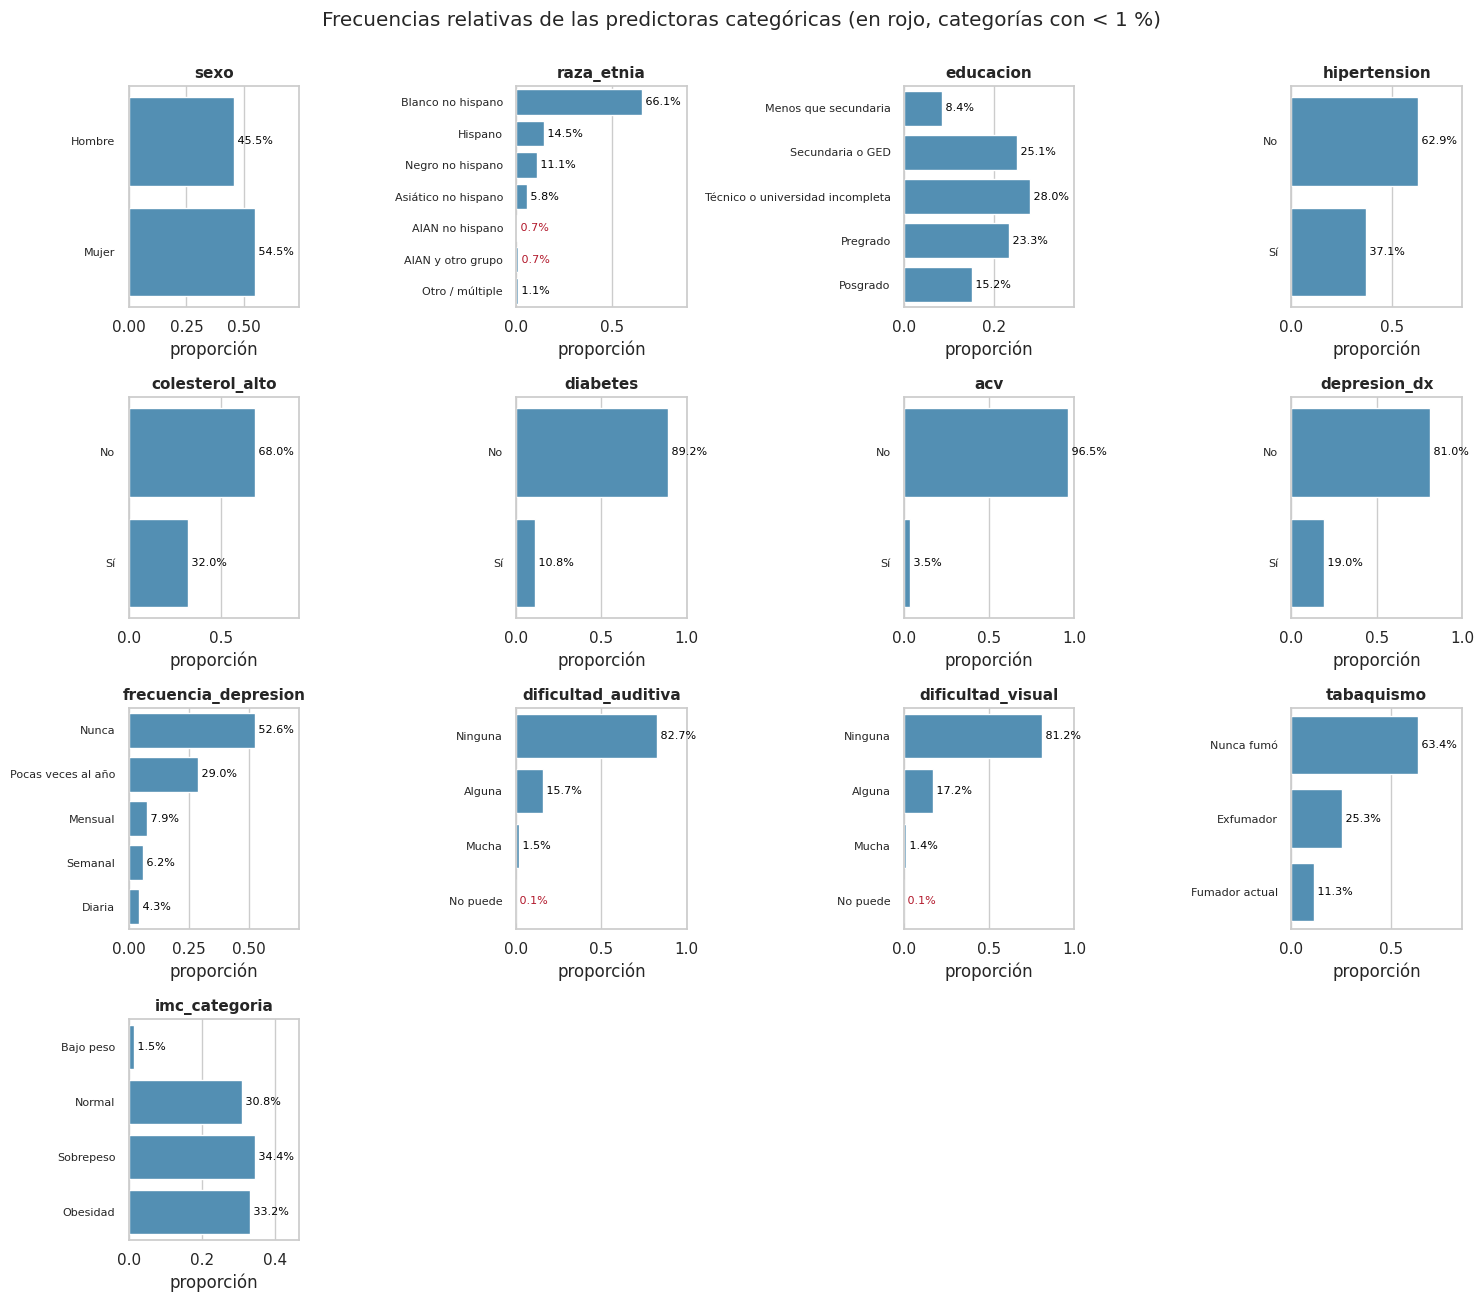

In [7]:
fig, axes = plt.subplots(4, 4, figsize=(15, 13))
for ax, v in zip(axes.ravel(), PREDICTORAS_CAT):
    orden = CATEGORIAS.get(v) or ORDENES.get(v)
    vc = train[v].value_counts(normalize=True).reindex(orden)
    sns.barplot(y=[str(c) for c in vc.index], x=vc.values, ax=ax, color="#4393c3", orient="h")
    for i, p in enumerate(vc.values):
        ax.text(p, i, f" {p:.1%}", va="center", fontsize=8, color="#b2182b" if p < 0.01 else "black")
    ax.set_title(v); ax.set_xlim(0, min(1.0, vc.max() * 1.35)); ax.set_xlabel("proporción")
    ax.tick_params(axis="y", labelsize=8)
for ax in axes.ravel()[len(PREDICTORAS_CAT):]:
    ax.axis("off")
plt.suptitle("Frecuencias relativas de las predictoras categóricas (en rojo, categorías con < 1 %)", y=1.0)
plt.tight_layout(); plt.show()

Todas las predictoras categóricas tienen cardinalidad baja, entre 2 y 7 niveles, así que la
codificación one-hot no debería generar problemas de dimensionalidad. Los perfiles más frecuentes
describen a un adulto sin hipertensión (62,9 %), sin diabetes (89,2 %), sin antecedente de ACV
(96,5 %) y que nunca fumó (63,4 %). El ACV es la condición más rara, con 3,5 % de la muestra y unos
1 560 casos en entrenamiento, suficiente para estimar su efecto aunque con intervalos más amplios.

Hay algunas categorías raras, por debajo del 1 %: AIAN no hispano (0,67 %) y AIAN y otro grupo
(0,70 %) dentro de raza y etnia, y no puede en dificultad auditiva (0,07 %) y visual (0,11 %). Con
tan pocos casos, sus coeficientes serían inestables y su prevalencia muy imprecisa, así que para el
preprocesamiento se decide agrupar las categorías AIAN con otro o múltiple (1,1 %, también pequeña y
heterogénea) y no puede con mucha.


## 2.3 Análisis bidimensional

### 2.3.1 Numéricas vs. numéricas

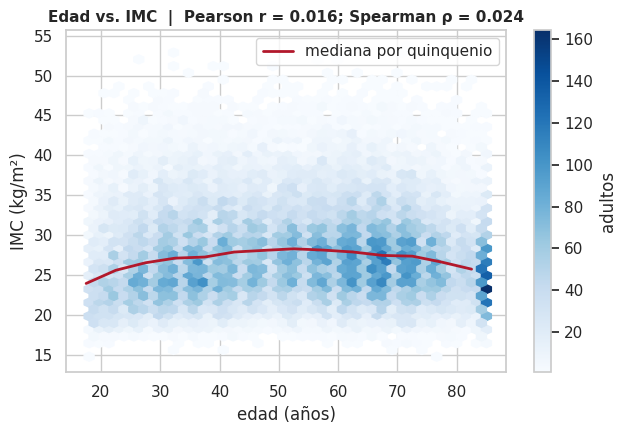

Pearson r = 0.016 (p = 1.5e-03); Spearman rho = 0.024 (p = 7.5e-07); n = 41,029


In [8]:
par = train[["edad", "imc"]].dropna()
r_p, p_p = stats.pearsonr(par["edad"], par["imc"])
r_s, p_s = stats.spearmanr(par["edad"], par["imc"])
fig, ax = plt.subplots(figsize=(6.5, 4.5))
hb = ax.hexbin(par["edad"], par["imc"], gridsize=40, cmap="Blues", mincnt=1)
plt.colorbar(hb, ax=ax, label="adultos")
medias = par.groupby(pd.cut(par["edad"], range(15, 90, 5)), observed=True)["imc"].median()
ax.plot([i.mid for i in medias.index], medias.values, color="#b2182b", lw=2, label="mediana por quinquenio")
ax.set_xlabel("edad (años)"); ax.set_ylabel("IMC (kg/m²)"); ax.legend()
ax.set_title(f"Edad vs. IMC  |  Pearson r = {r_p:.3f}; Spearman ρ = {r_s:.3f}")
plt.tight_layout(); plt.show()
print(f"Pearson r = {r_p:.3f} (p = {p_p:.1e}); Spearman rho = {r_s:.3f} (p = {p_s:.1e}); n = {len(par):,}")

Edad e IMC prácticamente no están correlacionados: Pearson r = 0,016 y Spearman ρ = 0,024. Los
valores p resultan significativos solo por el enorme tamaño de la muestra, ya que una correlación de
0,02 explica menos del 0,1 % de la varianza. La mediana por quinquenio sí muestra una relación suave
y no lineal, el IMC sube hasta los 50-60 años y luego baja, que el coeficiente lineal no logra
capturar. Para el modelo esto implica que la edad y el estado nutricional aportan información no
redundante.


### 2.3.2 Categóricas vs. numéricas

Primero se mira la edad según la variable objetivo, luego la prevalencia de dificultad cognitiva por
grupo de edad, que es lo que revela la forma real de la relación, y por último la edad en cada
categoría de las demás predictoras, con Kruskal-Wallis y su tamaño de efecto ε².


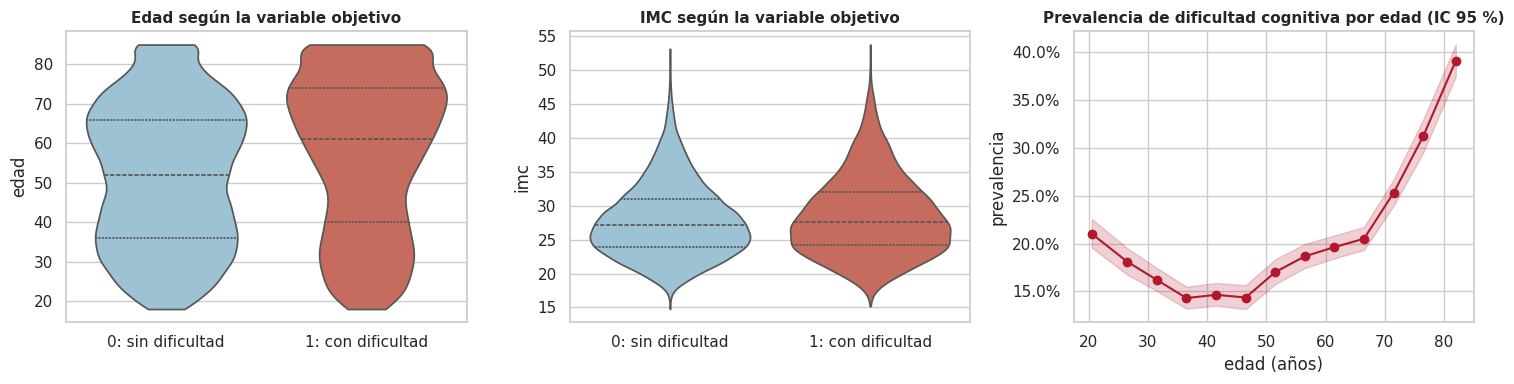

variable,mediana con dificultad,mediana sin dificultad,p (Mann-Whitney),r biserial por rangos
edad,61.0,52.0,2.0e-147,0.174
imc,27.6,27.2,2.3e-16,0.058


In [9]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
sns.violinplot(data=train, x=OBJETIVO, y="edad", ax=axes[0], palette=["#92c5de", "#d6604d"], cut=0, inner="quartile")
axes[0].set_xticks([0, 1], ["0: sin dificultad", "1: con dificultad"]); axes[0].set_xlabel("")
axes[0].set_title("Edad según la variable objetivo")
sns.violinplot(data=train, x=OBJETIVO, y="imc", ax=axes[1], palette=["#92c5de", "#d6604d"], cut=0, inner="quartile")
axes[1].set_xticks([0, 1], ["0: sin dificultad", "1: con dificultad"]); axes[1].set_xlabel("")
axes[1].set_title("IMC según la variable objetivo")

grupos = pd.cut(train["edad"], [17, 24, 29, 34, 39, 44, 49, 54, 59, 64, 69, 74, 79, 85])
prev_edad = train.groupby(grupos, observed=True)[OBJETIVO].apply(prev_ic).unstack()
x_mid = [i.mid for i in prev_edad.index]
axes[2].plot(x_mid, prev_edad["prevalencia"], "o-", color="#b2182b")
axes[2].fill_between(x_mid, prev_edad["ic_inf"], prev_edad["ic_sup"], alpha=0.2, color="#b2182b")
axes[2].yaxis.set_major_formatter(plt.matplotlib.ticker.PercentFormatter(1))
axes[2].set_xlabel("edad (años)"); axes[2].set_ylabel("prevalencia")
axes[2].set_title("Prevalencia de dificultad cognitiva por edad (IC 95 %)")
plt.tight_layout(); plt.show()

filas = []
for var in ["edad", "imc"]:
    a = train.loc[y == 1, var].dropna(); b = train.loc[y == 0, var].dropna()
    u = stats.mannwhitneyu(a, b)
    r_rb = 2 * u.statistic / (len(a) * len(b)) - 1
    filas.append([var, a.median(), b.median(), u.pvalue, r_rb])
display(pd.DataFrame(filas, columns=["variable", "mediana con dificultad", "mediana sin dificultad",
                                     "p (Mann-Whitney)", "r biserial por rangos"])
        .style.hide(axis="index").format({"p (Mann-Whitney)": "{:.1e}", "r biserial por rangos": "{:.3f}",
                                          "mediana con dificultad": "{:.1f}", "mediana sin dificultad": "{:.1f}"}))

In [10]:
filas = []
for v in PREDICTORAS_CAT:
    sub = train[[v, "edad"]].dropna()
    grupos_v = [g["edad"].values for _, g in sub.groupby(v)]
    h, p = stats.kruskal(*grupos_v)
    k, n_v = len(grupos_v), len(sub)
    eps2 = max(0.0, (h - k + 1) / (n_v - k))
    medianas = sub.groupby(v)["edad"].median()
    filas.append([v, h, p, eps2, f"{medianas.idxmin()} ({medianas.min():.0f}) → {medianas.idxmax()} ({medianas.max():.0f})"])
kw = pd.DataFrame(filas, columns=["variable", "H", "p", "ε²", "edad mediana: mín → máx"])
kw["p (Holm)"] = multipletests(kw["p"], method="holm")[1]
kw = kw.sort_values("ε²", ascending=False)
display(kw.style.hide(axis="index").format({"H": "{:,.0f}", "p": "{:.1e}", "p (Holm)": "{:.1e}", "ε²": "{:.3f}"})
        .bar(subset="ε²", color="#f4a582"))

variable,H,p,ε²,edad mediana: mín → máx,p (Holm)
hipertension,"8,626",0.0e+00,0.193,No (44) → Sí (66),0.0e+00
colesterol_alto,"6,818",0.0e+00,0.153,No (46) → Sí (66),0.0e+00
dificultad_auditiva,"2,862",0.0e+00,0.064,Ninguna (51) → Mucha (69),0.0e+00
raza_etnia,"2,558",0.0e+00,0.057,Otro / múltiple (36) → Blanco no hispano (58),0.0e+00
diabetes,"2,156",0.0e+00,0.048,No (52) → Sí (66),0.0e+00
tabaquismo,"1,941",0.0e+00,0.045,Nunca fumó (50) → Exfumador (63),0.0e+00
acv,"1,219",4.5e-267,0.027,No (53) → Sí (71),3.1e-266
frecuencia_depresion,653,4.9e-140,0.015,Mensual (45) → Nunca (57),2.9e-139
dificultad_visual,551,3.6e-119,0.012,Ninguna (52) → No puede (66),1.8e-118
educacion,434,1.1e-92,0.010,Pregrado (49) → Menos que secundaria (60),4.4e-92


Quienes reportan dificultad cognitiva son mayores, con una mediana de 61 años frente a 52, aunque el
efecto es pequeño (r biserial = 0,17). El hallazgo más importante, sin embargo, está en la forma de
la curva de prevalencia: la relación no es monótona, sino en forma de U. La prevalencia es del 21 %
entre los 18 y los 24 años, baja hasta un mínimo de cerca del 14 % entre los 35 y los 49, y luego
sube de forma sostenida hasta el 39 % en los mayores de 79. La dificultad cognitiva de los adultos
jóvenes probablemente refleja factores distintos al envejecimiento, como la atención, la ansiedad o
el sueño, mientras que la de los mayores se asocia más al envejecimiento cerebral. Como un término
lineal de edad no puede representar una forma de U, se decide modelar la edad con splines cúbicos
dentro del pipeline.

Entre IMC y dificultad cognitiva la diferencia de medianas es mínima (27,6 frente a 27,2 kg/m², con
r = 0,06, un efecto despreciable), lo que es coherente con la débil asociación que ya mostraba la
categoría de IMC.

La edad, comparada con las demás predictoras, está fuertemente relacionada con la hipertensión
(ε² = 0,19) y el colesterol alto (ε² = 0,15): quienes tienen estas condiciones son en promedio 20
años mayores. También se relaciona, aunque menos, con la pérdida auditiva (ε² = 0,06). Esto anticipa
un problema de confusión por edad, porque parte de la asociación cruda de estos factores con la
dificultad cognitiva se debe simplemente a que son marcadores de mayor edad, y el modelo
multivariado tendrá que ajustar por ella.


### 2.3.3 Categóricas vs. categóricas (cada predictora vs. la variable objetivo)

In [11]:
filas = []
for v in PREDICTORAS_CAT:
    tab = pd.crosstab(train[v], y)
    chi2, p, dof, esperadas = stats.chi2_contingency(tab)
    filas.append([v, chi2, dof, p, cramers_v(tab), (esperadas < 5).sum()])
asoc = pd.DataFrame(filas, columns=["variable", "chi2", "gl", "p", "V de Cramér", "celdas esperadas < 5"])
asoc["p (Holm)"] = multipletests(asoc["p"], method="holm")[1]
asoc["magnitud"] = pd.cut(asoc["V de Cramér"], [-0.01, 0.1, 0.3, 0.5, 1], labels=["despreciable", "pequeña", "moderada", "grande"])
asoc = asoc.sort_values("V de Cramér", ascending=False)
display(asoc.style.hide(axis="index").format({"chi2": "{:,.1f}", "p": "{:.1e}", "p (Holm)": "{:.1e}",
                                              "V de Cramér": "{:.3f}"}).bar(subset="V de Cramér", color="#f4a582"))

variable,chi2,gl,p,V de Cramér,celdas esperadas < 5,p (Holm),magnitud
frecuencia_depresion,"4,327.2",4,0.0e+00,0.314,0,0.0e+00,moderada
depresion_dx,"3,664.4",1,0.0e+00,0.286,0,0.0e+00,pequeña
dificultad_auditiva,"2,688.5",3,0.0e+00,0.245,0,0.0e+00,pequeña
dificultad_visual,"2,373.8",3,0.0e+00,0.230,0,0.0e+00,pequeña
colesterol_alto,685.9,1,3.6e-151,0.124,0,3.2e-150,pequeña
hipertension,650.8,1,1.5e-143,0.120,0,1.2e-142,pequeña
acv,599.5,1,2.2e-132,0.116,0,1.5e-131,pequeña
educacion,576.3,4,2.1e-123,0.113,0,1.3e-122,pequeña
tabaquismo,493.3,2,7.5e-108,0.106,0,3.7e-107,pequeña
diabetes,420.8,1,1.6e-93,0.097,0,6.5e-93,despreciable


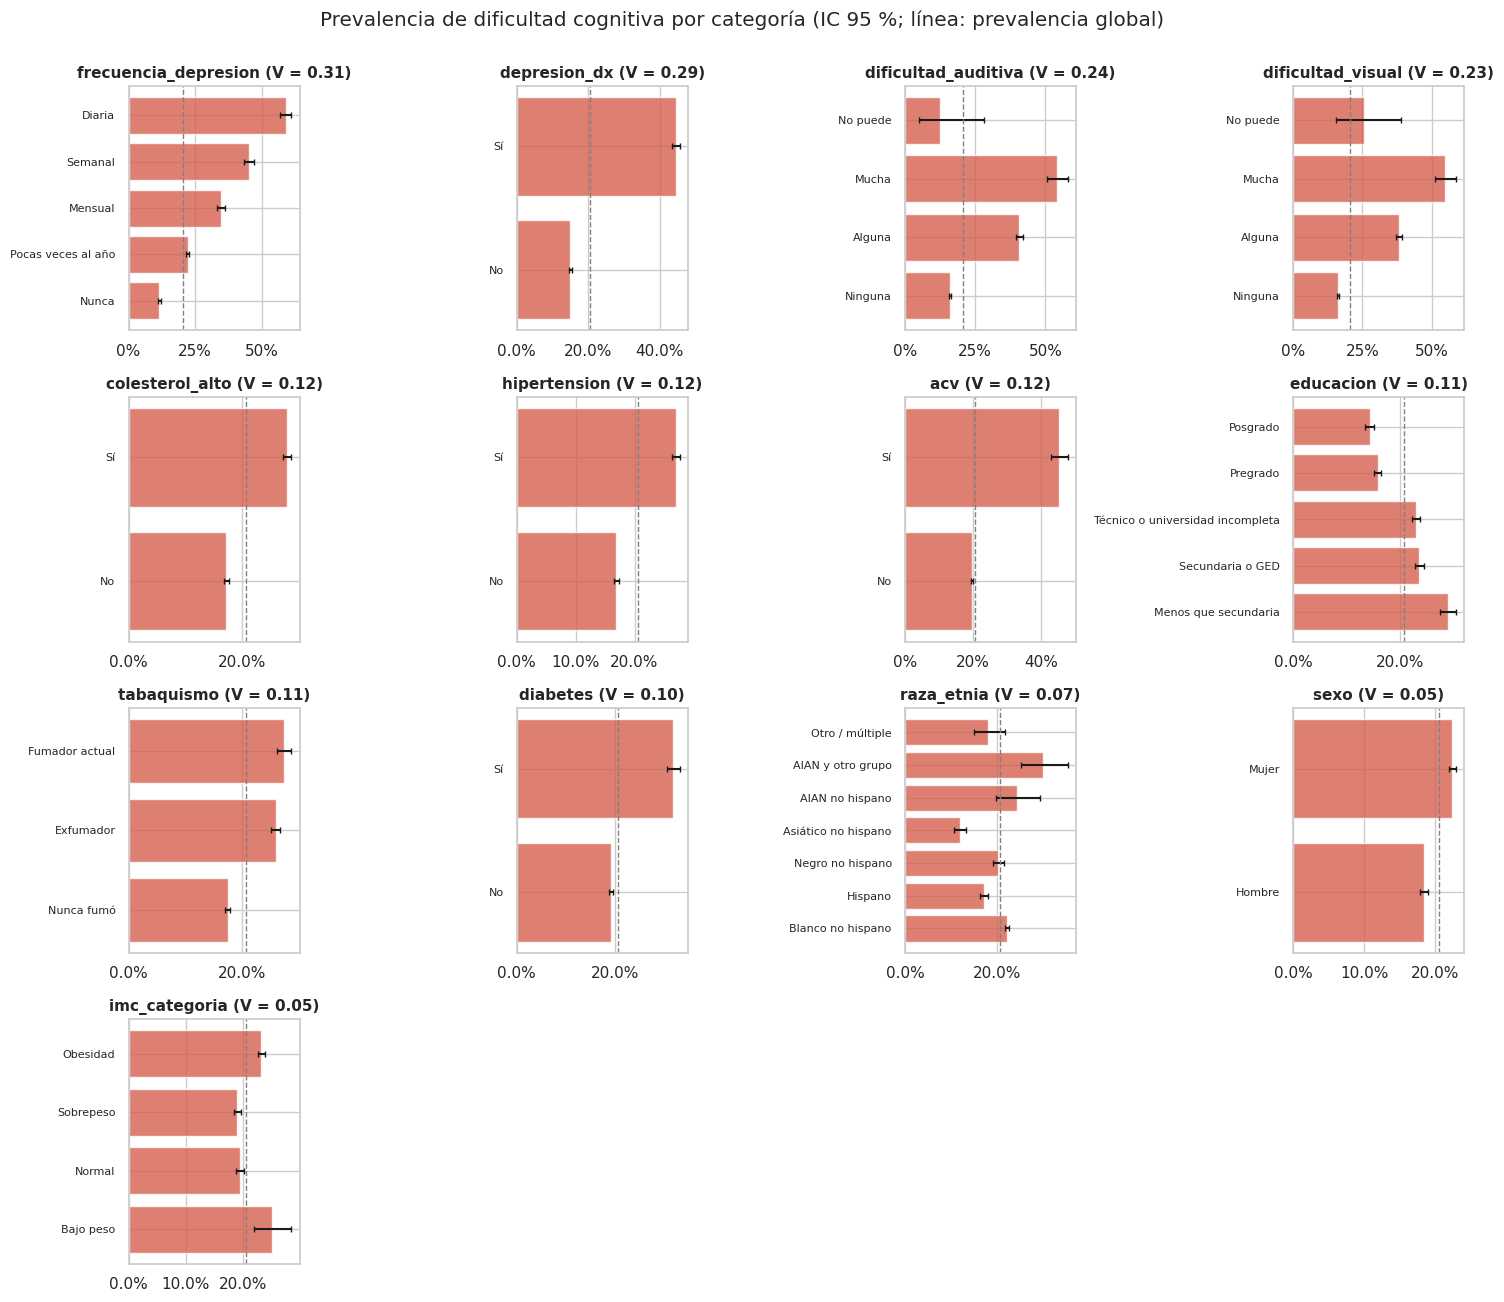

In [12]:
fig, axes = plt.subplots(4, 4, figsize=(15, 13))
for ax, v in zip(axes.ravel(), asoc["variable"]):
    orden = [c for c in (CATEGORIAS.get(v) or ORDENES.get(v)) if c in set(train[v].dropna())]
    pv = train.groupby(v)[OBJETIVO].apply(prev_ic).unstack().reindex(orden)
    ax.barh([str(c) for c in pv.index], pv["prevalencia"], xerr=[pv["prevalencia"] - pv["ic_inf"],
            pv["ic_sup"] - pv["prevalencia"]], color="#d6604d", alpha=0.8, capsize=2)
    ax.axvline(y.mean(), color="gray", ls="--", lw=1)
    ax.xaxis.set_major_formatter(plt.matplotlib.ticker.PercentFormatter(1))
    ax.set_title(f"{v} (V = {asoc.set_index('variable').loc[v, 'V de Cramér']:.2f})"); ax.tick_params(axis="y", labelsize=8)
for ax in axes.ravel()[len(PREDICTORAS_CAT):]:
    ax.axis("off")
plt.suptitle("Prevalencia de dificultad cognitiva por categoría (IC 95 %; línea: prevalencia global)", y=1.0)
plt.tight_layout(); plt.show()

Tras la corrección de Holm, las 13 predictoras siguen asociadas con la dificultad cognitiva, todas
con p menor a 10⁻²¹, así que en este punto la significación ya no discrimina nada: lo que importa es
la magnitud, medida con la V de Cramér.

El bloque más fuerte es el de salud mental. La frecuencia de síntomas depresivos tiene la asociación
más alta (V = 0,31, moderada) y un gradiente dosis-respuesta muy claro: la prevalencia pasa de
11,6 % en quienes nunca se sienten deprimidos a 59,0 % en quienes se sienten así todos los días. El
diagnóstico de depresión le sigue de cerca (V = 0,29; 44,5 % frente a 15,0 %).

Las pérdidas sensoriales van después. La dificultad auditiva (V = 0,25) y la visual (V = 0,23)
también muestran un gradiente: la prevalencia es del 16 % sin dificultad, cerca de 40 % con alguna
dificultad y de 54 a 55 % con mucha. La categoría no puede rompe el gradiente, pero sus intervalos
son muy amplios por tener pocos casos, lo que confirma que agruparla fue la decisión correcta.

Los factores vasculares y de estilo de vida tienen asociaciones más pequeñas, con V entre 0,10 y
0,12: colesterol alto (27,9 % frente a 17,2 %), hipertensión (27,0 % frente a 16,9 %), ACV (45,3 %
frente a 19,7 %), diabetes, tabaquismo y baja escolaridad (28,9 % sin secundaria frente a 14,3 % con
posgrado).

Raza y etnia, sexo e IMC tienen asociaciones despreciables (V < 0,08). La categoría de IMC muestra
una leve forma de U, con más prevalencia en bajo peso y en obesidad que en peso normal o sobrepeso,
por lo que conviene codificarla con one-hot en lugar de tratarla como variable ordinal lineal.

En conjunto, estos resultados son coherentes con la literatura: los factores de la Comisión Lancet se
asocian con la dificultad cognitiva en la dirección esperada, lo que respalda la validez de la
variable objetivo.


### 2.3.4 Foco en la exposición de interés: antecedente de ACV

El ACV se asocia con la edad, y la edad con la dificultad cognitiva, así que la asociación cruda
entre ACV y dificultad cognitiva puede estar confundida por la edad. Para revisarlo se compara el
odds ratio crudo con el odds ratio de Mantel-Haenszel, ajustado por grupo de edad.


Tabla 2x2 (filas: ACV sí/no; columnas: dificultad sí/no)


dificultad_cognitiva,1,0
acv_si,,
1,705,854
0,8523,34664


OR crudo = 3.36 (IC 95 %: 3.03–3.72)
OR por grupo de edad: {'18-44': 4.72, '45-54': 3.43, '55-64': 3.83, '65-74': 2.93, '75+': 1.68}
OR de Mantel-Haenszel ajustado por edad = 2.52 (IC 95 %: 2.27–2.80)
Prueba de homogeneidad de Breslow-Day: p = 0.000


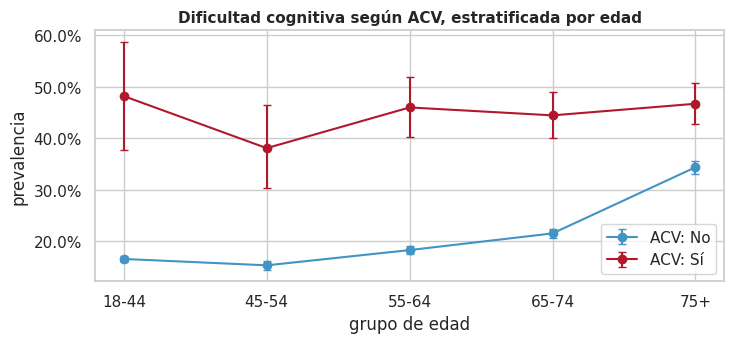

grupo_edad,18-44,45-54,55-64,65-74,75+
acv,,,,,
n (ACV No),16284,6131,7591,7775,5406
n (ACV Sí),83,134,274,477,591


In [13]:
from statsmodels.stats.contingency_tables import Table2x2, StratifiedTable

sub = train.dropna(subset=["acv", "edad"]).copy()
sub["acv_si"] = (sub["acv"] == "Sí").astype(int)
t = pd.crosstab(sub["acv_si"], sub[OBJETIVO]).loc[[1, 0], [1, 0]]
crudo = Table2x2(t.values)
print("Tabla 2x2 (filas: ACV sí/no; columnas: dificultad sí/no)"); display(t)
print(f"OR crudo = {crudo.oddsratio:.2f} (IC 95 %: {crudo.oddsratio_confint()[0]:.2f}–{crudo.oddsratio_confint()[1]:.2f})")

sub["grupo_edad"] = pd.cut(sub["edad"], [17, 44, 54, 64, 74, 85], labels=["18-44", "45-54", "55-64", "65-74", "75+"])
tablas = [pd.crosstab(g["acv_si"], g[OBJETIVO]).reindex(index=[1, 0], columns=[1, 0], fill_value=0).values
          for _, g in sub.groupby("grupo_edad", observed=True)]
mh = StratifiedTable(tablas)
or_estrato = pd.Series([Table2x2(tb + 0.5).oddsratio for tb in tablas],
                       index=sub["grupo_edad"].cat.categories, name="OR por estrato")
print("OR por grupo de edad:", or_estrato.round(2).to_dict())
print(f"OR de Mantel-Haenszel ajustado por edad = {mh.oddsratio_pooled:.2f} "
      f"(IC 95 %: {mh.oddsratio_pooled_confint()[0]:.2f}–{mh.oddsratio_pooled_confint()[1]:.2f})")
print(f"Prueba de homogeneidad de Breslow-Day: p = {mh.test_equal_odds().pvalue:.3f}")

pv = sub.groupby(["grupo_edad", "acv"], observed=True)[OBJETIVO].apply(prev_ic).unstack()
fig, ax = plt.subplots(figsize=(7.5, 3.6))
for acv, color in [("No", "#4393c3"), ("Sí", "#b2182b")]:
    d = pv.xs(acv, level="acv")
    ax.errorbar(d.index.astype(str), d["prevalencia"], yerr=[d["prevalencia"] - d["ic_inf"], d["ic_sup"] - d["prevalencia"]],
                fmt="o-", capsize=3, color=color, label=f"ACV: {acv}")
ax.yaxis.set_major_formatter(plt.matplotlib.ticker.PercentFormatter(1)); ax.legend()
ax.set_xlabel("grupo de edad"); ax.set_ylabel("prevalencia"); ax.set_title("Dificultad cognitiva según ACV, estratificada por edad")
plt.tight_layout(); plt.show()
display(pv["n"].unstack().rename(columns=lambda c: f"n (ACV {c})").astype(int).T)

Entre quienes tuvieron un ACV, el 45,3 % reporta dificultad cognitiva, frente al 19,7 % de quienes no
lo tuvieron. El OR crudo es de 3,36 (IC 95 %: 3,03-3,72). Pero el ACV es mucho más frecuente en
edades avanzadas, con 591 casos en mayores de 75 años frente a 83 en menores de 45, y la edad
también eleva por sí misma la dificultad cognitiva. Al ajustar por grupo de edad con
Mantel-Haenszel, el OR baja a 2,52 (IC 95 %: 2,27-2,80). Es decir, cerca de un tercio del exceso de
odds crudo se explica por la edad, pero la asociación sigue siendo fuerte e independiente.

Además, la prueba de Breslow-Day (p < 0,001) muestra que el efecto no es homogéneo entre edades: el
OR es de 4,7 en menores de 45 años y cae a 1,7 en mayores de 75. El gráfico ayuda a entender por qué:
en los adultos jóvenes, tener un ACV multiplica la prevalencia de dificultad cognitiva, de 16,5 % a
48,2 %, mientras que en los mayores de 75 la prevalencia de base ya es alta (34,3 %) y el ACV añade
relativamente menos (46,7 %). Esto sugiere una interacción entre ACV y edad que un modelo lineal sin
interacciones no va a capturar, y queda anotada como una oportunidad para los modelos de las
siguientes entregas.


### 2.3.5 Predictoras vs. objetivo: información mutua

La información mutua captura cualquier tipo de dependencia, incluidas las que son no lineales y no
monótonas, como la de la edad, que la correlación simple no logra detectar.


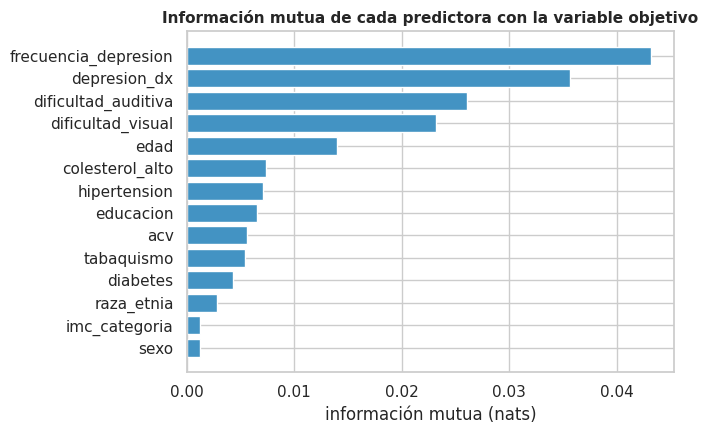

In [14]:
from sklearn.feature_selection import mutual_info_classif

X_mi = pd.DataFrame(index=train.index)
for v in PREDICTORAS_CAT:
    X_mi[v] = train[v].astype("category").cat.codes  # los faltantes quedan como categoría propia (-1)
X_mi["edad"] = train["edad"].fillna(train["edad"].median())
mi = mutual_info_classif(X_mi, y, discrete_features=[c != "edad" for c in X_mi.columns], random_state=SEED)
mi = pd.Series(mi, index=X_mi.columns).sort_values()
fig, ax = plt.subplots(figsize=(7, 4.5))
ax.barh(mi.index, mi.values, color="#4393c3"); ax.set_xlabel("información mutua (nats)")
ax.set_title("Información mutua de cada predictora con la variable objetivo")
plt.tight_layout(); plt.show()

La información mutua ordena las predictoras casi igual que la V de Cramér: la frecuencia de
síntomas depresivos, el diagnóstico de depresión y las dificultades auditiva y visual encabezan la
lista, seguidas por la edad, que aquí sube hasta el quinto lugar. Esto tiene sentido, porque la edad
tiene una asociación lineal débil con el objetivo (r biserial = 0,17), pero la información mutua sí
detecta su relación en forma de U. Los valores absolutos son bajos en todos los casos, por debajo de
0,05 nats, lo que indica que ninguna variable por sí sola determina el objetivo. El desempeño del
modelo va a depender de combinar muchas señales débiles, y no se esperan métricas cercanas a 1.


### 2.3.6 Asociación entre predictoras y multicolinealidad

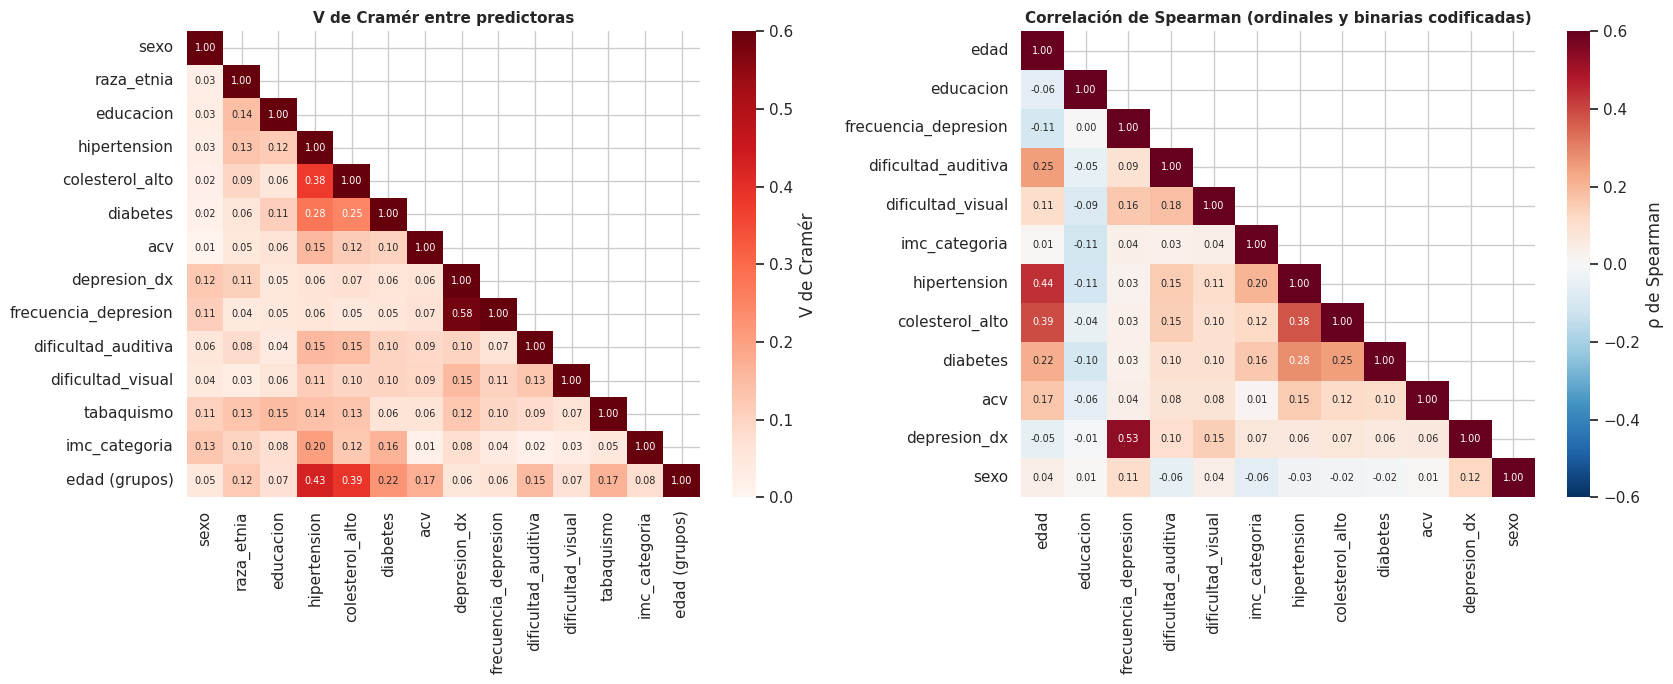

Pares con mayor asociación (V de Cramér):
depresion_dx     frecuencia_depresion   0.5840
hipertension     edad (grupos)          0.4310
colesterol_alto  edad (grupos)          0.3890
hipertension     colesterol_alto        0.3770
                 diabetes               0.2770
colesterol_alto  diabetes               0.2500


In [15]:
vars_assoc = PREDICTORAS_CAT + ["edad (grupos)"]
tmp = train[PREDICTORAS_CAT].copy()
tmp["edad (grupos)"] = pd.cut(train["edad"], [17, 34, 49, 64, 74, 85])
mat = pd.DataFrame(np.eye(len(vars_assoc)), index=vars_assoc, columns=vars_assoc)
for i, a in enumerate(vars_assoc):
    for b in vars_assoc[i + 1:]:
        mat.loc[a, b] = mat.loc[b, a] = cramers_v(pd.crosstab(tmp[a], tmp[b]))

ordinales = ["edad", "educacion", "frecuencia_depresion", "dificultad_auditiva", "dificultad_visual", "imc_categoria",
             "hipertension", "colesterol_alto", "diabetes", "acv", "depresion_dx", "sexo"]
ordn = pd.DataFrame({v: train[v] if v == "edad" else a_ordinal(train[v], v) for v in ordinales})
spear = ordn.corr(method="spearman")

fig, axes = plt.subplots(1, 2, figsize=(17, 7))
mask = np.triu(np.ones_like(mat, dtype=bool), 1)
sns.heatmap(mat, mask=mask, annot=True, fmt=".2f", cmap="Reds", vmin=0, vmax=0.6, ax=axes[0], annot_kws={"size": 7},
            cbar_kws={"label": "V de Cramér"})
axes[0].set_title("V de Cramér entre predictoras")
sns.heatmap(spear, mask=np.triu(np.ones_like(spear, dtype=bool), 1), annot=True, fmt=".2f", cmap="RdBu_r",
            vmin=-0.6, vmax=0.6, center=0, ax=axes[1], annot_kws={"size": 7}, cbar_kws={"label": "ρ de Spearman"})
axes[1].set_title("Correlación de Spearman (ordinales y binarias codificadas)")
plt.tight_layout(); plt.show()

pares = (mat.where(np.triu(np.ones_like(mat, dtype=bool), 1)).stack().sort_values(ascending=False).head(6))
print("Pares con mayor asociación (V de Cramér):"); print(pares.round(3).to_string())

In [16]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Para el VIF se usa la edad lineal (los splines son colineales por construcción)
completos = train[PREDICTORAS].dropna()
X_vif = dummies_referencia(completos)
X_vif["edad"] = completos["edad"]
X_vif.insert(0, "constante", 1.0)
vif = pd.Series([variance_inflation_factor(X_vif.values, i) for i in range(1, X_vif.shape[1])],
                index=X_vif.columns[1:]).sort_values(ascending=False)
display(vif.head(12).rename("VIF").to_frame().style.format("{:.2f}").bar(color="#f4a582"))
print(f"VIF máximo = {vif.max():.2f}; columnas con VIF > 5: {(vif > 5).sum()}; con VIF > 10: {(vif > 10).sum()}")

,VIF
educacion_Técnico o universidad incompleta,3.38
educacion_Pregrado,3.28
educacion_Secundaria o GED,3.15
educacion_Posgrado,2.69
edad,1.60
depresion_dx_Sí,1.57
imc_categoria_Obesidad,1.54
imc_categoria_Sobrepeso,1.44
hipertension_Sí,1.44
frecuencia_depresion_Semanal,1.32


VIF máximo = 3.38; columnas con VIF > 5: 0; con VIF > 10: 0


El par de predictoras más asociado es el diagnóstico de depresión con la frecuencia de síntomas
depresivos (V = 0,58), algo esperable porque miden el mismo constructo desde dos ángulos distintos:
la historia diagnóstica y los síntomas actuales. Le siguen la hipertensión con la edad (0,43) y con
el colesterol alto (0,38), que es el conocido agrupamiento de riesgo cardiometabólico junto con el
envejecimiento.

Aun así, no hay multicolinealidad problemática. Con las categorías de referencia del modelo, el VIF
máximo es 3,38, en las categorías de educación, que son mutuamente excluyentes, y ninguna columna
supera 5. La correlación de Spearman confirma que las asociaciones son como máximo moderadas. Se
decide conservar ambas variables de depresión, porque aportan información distinta (sección 1.9.5),
y la regularización L2 de la regresión logística amortigua cualquier inestabilidad residual en los
coeficientes.


### 2.3.7 Selección preliminar de variables

In [17]:
sel = asoc.set_index("variable")[["V de Cramér", "p (Holm)"]].copy()
sel.loc["edad", "V de Cramér"] = np.nan
sel["información mutua"] = mi
sel["rango IM"] = sel["información mutua"].rank(ascending=False).astype(int)
sel["decisión preliminar"] = "Conservar"
display(sel.sort_values("rango IM").style.format({"V de Cramér": "{:.3f}", "p (Holm)": "{:.1e}",
                                                   "información mutua": "{:.4f}"}, na_rep="—"))

,V de Cramér,p (Holm),información mutua,rango IM,decisión preliminar
variable,,,,,
frecuencia_depresion,0.314,0.0e+00,0.0432,1,Conservar
depresion_dx,0.286,0.0e+00,0.0356,2,Conservar
dificultad_auditiva,0.245,0.0e+00,0.0261,3,Conservar
dificultad_visual,0.230,0.0e+00,0.0232,4,Conservar
edad,—,—,0.0140,5,Conservar
colesterol_alto,0.124,3.2e-150,0.0074,6,Conservar
hipertension,0.120,1.2e-142,0.0071,7,Conservar
educacion,0.113,1.3e-122,0.0065,8,Conservar
acv,0.116,1.5e-131,0.0056,9,Conservar


Con base en todo lo anterior, se conservan las 14 predictoras:

1. Todas tienen una asociación con el objetivo distinta de cero después de corregir por
   comparaciones múltiples.
2. Ninguna es redundante, con VIF por debajo de 5.
3. Cada una está justificada por la literatura: el marco de la Comisión Lancet 2024, el ACV como
   exposición de interés, y la edad, el sexo y la raza o etnia como variables de ajuste.
4. Las de asociación despreciable, como sexo, IMC y raza o etnia, se mantienen como confusores:
   aunque predigan poco por sí solas, pueden modificar la estimación de los demás efectos una vez
   que el modelo ajusta por ellas.

La selección definitiva queda sujeta a la auditoría de fuga de datos de la sección 2.5, donde se
descartan las variables que no estarían disponibles de forma legítima al momento de predecir.


## 2.4 Análisis multivariado

### 2.4.1 Reducción de dimensionalidad exploratoria (PCA)

El PCA se aplica a las predictoras codificadas: one-hot con categoría de referencia, edad
estandarizada y faltantes imputados con la moda, solo para este análisis exploratorio. Se usa
únicamente como herramienta descriptiva, no inferencial.


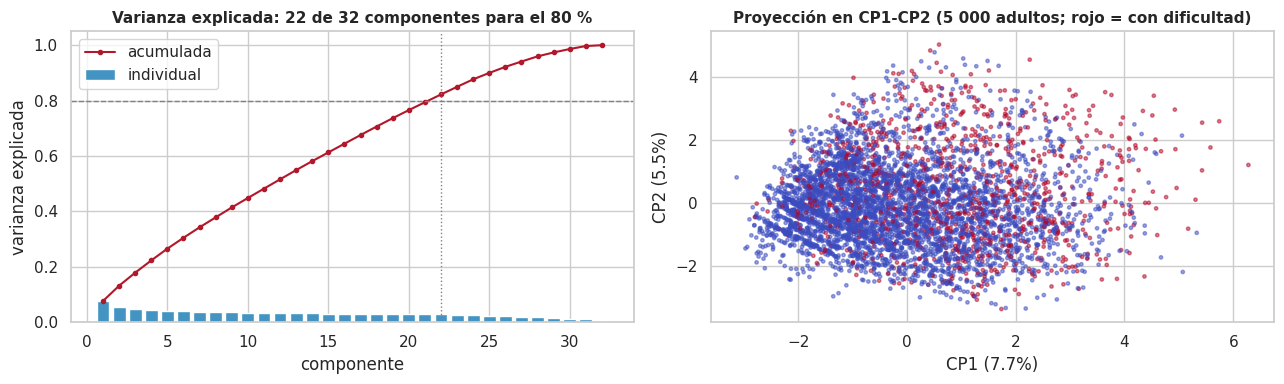

CP1 (7.7%): hipertension_Sí (+0.44), edad (+0.41), colesterol_alto_Sí (+0.39), diabetes_Sí (+0.32), dificultad_auditiva_Alguna (+0.24), acv_Sí (+0.21)
CP2 (5.5%): depresion_dx_Sí (+0.41), imc_categoria_Sobrepeso (-0.33), imc_categoria_Obesidad (+0.32), edad (-0.32), frecuencia_depresion_Diaria (+0.26), frecuencia_depresion_Semanal (+0.26)
CP3 (4.7%): imc_categoria_Obesidad (+0.51), imc_categoria_Sobrepeso (-0.45), depresion_dx_Sí (-0.39), frecuencia_depresion_Diaria (-0.24), frecuencia_depresion_Semanal (-0.24), educacion_Secundaria o GED (+0.20)
Primeras 2 componentes: 13.2% de la varianza; primeras 5: 26.6%; componentes para el 80 %: 22 de 32


In [18]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

X_enc = dummies_referencia(train[PREDICTORAS_CAT].fillna(train[PREDICTORAS_CAT].mode().iloc[0]))
X_enc["edad"] = train["edad"].fillna(train["edad"].median())
X_std = StandardScaler().fit_transform(X_enc)
pca = PCA(random_state=SEED).fit(X_std)
var_acum = np.cumsum(pca.explained_variance_ratio_)
k80 = int(np.argmax(var_acum >= 0.80) + 1)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].bar(range(1, len(var_acum) + 1), pca.explained_variance_ratio_, color="#4393c3", label="individual")
axes[0].plot(range(1, len(var_acum) + 1), var_acum, "o-", color="#b2182b", ms=3, label="acumulada")
axes[0].axhline(0.8, ls="--", color="gray", lw=1); axes[0].axvline(k80, ls=":", color="gray", lw=1)
axes[0].set_xlabel("componente"); axes[0].set_ylabel("varianza explicada"); axes[0].legend()
axes[0].set_title(f"Varianza explicada: {k80} de {len(var_acum)} componentes para el 80 %")
Z = pca.transform(X_std)[:, :2]
idx = np.random.RandomState(SEED).choice(len(Z), 5000, replace=False)
sc = axes[1].scatter(Z[idx, 0], Z[idx, 1], c=y.values[idx], cmap="coolwarm", s=6, alpha=0.5)
axes[1].set_xlabel(f"CP1 ({pca.explained_variance_ratio_[0]:.1%})"); axes[1].set_ylabel(f"CP2 ({pca.explained_variance_ratio_[1]:.1%})")
axes[1].set_title("Proyección en CP1-CP2 (5 000 adultos; rojo = con dificultad)")
plt.tight_layout(); plt.show()

cargas = pd.DataFrame(pca.components_[:3].T, index=X_enc.columns, columns=["CP1", "CP2", "CP3"])
for cp in ["CP1", "CP2", "CP3"]:
    top = cargas[cp].abs().sort_values(ascending=False).head(6).index
    print(f"{cp} ({pca.explained_variance_ratio_[int(cp[-1]) - 1]:.1%}): " +
          ", ".join(f"{c} ({cargas.loc[c, cp]:+.2f})" for c in top))
print(f"Primeras 2 componentes: {var_acum[1]:.1%} de la varianza; primeras 5: {var_acum[4]:.1%}; componentes para el 80 %: {k80} de {len(var_acum)}")

La varianza está muy repartida: la primera componente explica solo el 7,7 %, las dos primeras juntas
el 13,2 %, y se necesitan 22 de las 32 componentes para llegar al 80 %. Esto significa que la
dimensionalidad efectiva es alta en relación con el número de variables, es decir que las
predictoras son poco redundantes entre sí, coherente con los VIF bajos, así que reducir dimensiones
no traería ninguna ventaja real.

La primera componente funciona como un eje cardiometabólico y de envejecimiento, donde cargan
hipertensión, edad, colesterol, diabetes, pérdida auditiva y ACV. La segunda es más bien un eje de
salud mental, donde cargan el diagnóstico de depresión y la frecuencia de síntomas, con la edad en
sentido opuesto, porque los síntomas depresivos son más frecuentes en adultos jóvenes. La tercera
componente se asocia principalmente al peso corporal.

En la proyección de las dos primeras componentes, los adultos con dificultad cognitiva tienden a
ubicarse hacia valores altos de ambos ejes, pero las dos clases se superponen ampliamente: no hay
una separación lineal simple, lo que vuelve a anticipar un desempeño moderado para el modelo base.


### 2.4.2 Outliers multivariados

In [19]:
from sklearn.ensemble import IsolationForest

# (a) Distancia de Mahalanobis en el espacio numérico (edad, IMC)
par = train[["edad", "imc"]].dropna()
cov_inv = np.linalg.inv(np.cov(par.values.T))
dif = par.values - par.values.mean(axis=0)
d2 = np.einsum("ij,jk,ik->i", dif, cov_inv, dif)
umbral = stats.chi2.ppf(0.999, df=2)
print(f"Mahalanobis (edad, IMC): {(d2 > umbral).sum()} adultos ({(d2 > umbral).mean():.2%}) superan el percentil 99,9 de chi2(2) = {umbral:.1f}")
print("   Perfil de esos casos:", par[d2 > umbral].describe().loc[["mean", "min", "max"]].round(1).to_dict())

# (b) Isolation Forest sobre todas las predictoras codificadas
iso = IsolationForest(n_estimators=300, contamination=0.01, random_state=SEED).fit(X_std)
atipico = iso.predict(X_std) == -1
perfil = pd.DataFrame({
    "atípicos (1 %)": [atipico.sum(), y[atipico].mean(), train.loc[atipico, "edad"].mean(),
                       (train.loc[atipico, "acv"] == "Sí").mean(), (train.loc[atipico, "dificultad_visual"].isin(["Mucha", "No puede"])).mean(),
                       (train.loc[atipico, "raza_etnia"].str.contains("AIAN|Otro")).mean()],
    "resto": [(~atipico).sum(), y[~atipico].mean(), train.loc[~atipico, "edad"].mean(),
              (train.loc[~atipico, "acv"] == "Sí").mean(), (train.loc[~atipico, "dificultad_visual"].isin(["Mucha", "No puede"])).mean(),
              (train.loc[~atipico, "raza_etnia"].str.contains("AIAN|Otro")).mean()]},
    index=["n", "prevalencia de dificultad cognitiva", "edad media", "% con ACV", "% con mucha dificultad visual",
           "% raza/etnia AIAN u otra"])
display(perfil.style.format("{:.3f}").format("{:,.0f}", subset=pd.IndexSlice["n", :]))

Mahalanobis (edad, IMC): 48 adultos (0.12%) superan el percentil 99,9 de chi2(2) = 13.8
   Perfil de esos casos: {'edad': {'mean': 50.7, 'min': 18.0, 'max': 82.0}, 'imc': {'mean': 49.5, 'min': 45.7, 'max': 53.7}}


,atípicos (1 %),resto
n,450,"44,453"
prevalencia de dificultad cognitiva,0.756,0.201
edad media,61.606,52.775
% con ACV,0.469,0.030
% con mucha dificultad visual,0.209,0.013
% raza/etnia AIAN u otra,0.111,0.024


Con la distancia de Mahalanobis sobre edad e IMC, solo 48 adultos (0,12 %) superan el umbral del
percentil 99,9, y todos tienen un IMC entre 45,7 y 53,7 kg/m², es decir obesidad severa: son valores
plausibles, no errores.

Con Isolation Forest sobre todas las predictoras, el 1 % más atípico tampoco está formado por
errores, sino por combinaciones raras de condiciones: el 46,9 % de este grupo tuvo un ACV, frente a
3,0 % en el resto; el 20,9 % tiene mucha dificultad visual, frente a 1,3 %; y su edad media es 9 años
mayor. En este grupo la prevalencia de dificultad cognitiva es del 75,6 %, casi cuatro veces la del
resto (20,1 %).

La decisión es no eliminarlos. Son personas reales con una alta carga de enfermedad, precisamente
las más relevantes para la pregunta de investigación, y sacarlas del análisis sesgaría el modelo
hacia la población más sana.


### 2.4.3 Estructura de grupos (clustering exploratorio)

In [20]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

Zk = pca.transform(X_std)[:, :k80]
idx_s = np.random.RandomState(SEED).choice(len(Zk), 6000, replace=False)
sil = {}
for k in range(2, 7):
    km = KMeans(n_clusters=k, n_init=10, random_state=SEED).fit(Zk)
    sil[k] = silhouette_score(Zk[idx_s], km.labels_[idx_s])
k_opt = max(sil, key=sil.get)
print("Silueta por k:", {k: round(v, 3) for k, v in sil.items()}, "-> k elegido =", k_opt)

km = KMeans(n_clusters=k_opt, n_init=10, random_state=SEED).fit(Zk)
g = pd.Series(km.labels_, index=train.index, name="cluster")
perfil_c = train.assign(cluster=g).groupby("cluster").agg(
    n=(OBJETIVO, "size"), prevalencia=(OBJETIVO, "mean"), edad_media=("edad", "mean"),
    hipertension=("hipertension", lambda s: (s == "Sí").mean()), depresion_dx=("depresion_dx", lambda s: (s == "Sí").mean()),
    mujeres=("sexo", lambda s: (s == "Mujer").mean()), fumador_actual=("tabaquismo", lambda s: (s == "Fumador actual").mean()),
    acv=("acv", lambda s: (s == "Sí").mean()))
display(perfil_c.style.format("{:.2f}").format({"n": "{:,}"}).background_gradient(subset=["prevalencia"], cmap="Reds"))

Silueta por k: {2: 0.098, 3: 0.099, 4: 0.09, 5: 0.09, 6: 0.122} -> k elegido = 6


,n,prevalencia,edad_media,hipertension,depresion_dx,mujeres,fumador_actual,acv
cluster,,,,,,,,
0,"1,907",0.590456,52.481890,0.493970,0.802307,0.609858,0.245936,0.090718
1,"9,635",0.172081,48.134527,0.243280,0.172081,0.569175,0.124650,0.005605
2,"9,343",0.133255,48.211249,0.233116,0.142460,0.539334,0.050412,0.006208
3,"8,166",0.353172,69.795711,0.896155,0.225569,0.543963,0.097845,0.145114
4,"6,351",0.125020,52.936463,0.277122,0.158243,0.562903,0.028814,0.007558
5,"9,501",0.162720,47.682130,0.220714,0.120724,0.502789,0.190717,0.004421


El coeficiente de silueta es bajo para todos los valores de k evaluados, entre 0,09 y 0,12: los
datos no forman grupos bien separados, sino más bien un continuo de perfiles de riesgo. Se reporta
la solución de k = 6, que es la de mayor silueta en el rango evaluado, solo como descripción, sin
atribuirle validez inferencial. Aun así, hay dos subpoblaciones que se distinguen con claridad.

El grupo 0, con unos 1 900 adultos, tiene un perfil de salud mental: el 80 % tiene diagnóstico de
depresión, el 25 % fuma y la prevalencia de dificultad cognitiva llega al 59 %, casi tres veces la
global. El grupo 3, con unos 8 200 adultos, tiene un perfil cardiometabólico y de mayor edad: edad
media de 70 años, 90 % con hipertensión y 15 % con ACV, con una prevalencia del 35 %.

Los otros cuatro grupos son adultos más jóvenes y sanos, con prevalencias entre 13 % y 17 %. Esto
sugiere que existen al menos dos rutas distintas hacia la dificultad cognitiva subjetiva, una
afectiva y otra vascular y de envejecimiento, algo que un modelo lineal aditivo captura solo
parcialmente y que los modelos no lineales podrían aprovechar mejor en las siguientes entregas.


## 2.6 a 2.8 Componentes temporal, espacial y espacio-temporal

- 2.6 Temporal: no aplica. El dataset no es una serie de tiempo. No hay mediciones repetidas de las
  mismas personas ni una variable de fecha u hora con dependencia temporal, solo se conocen el año y
  el trimestre de la entrevista. Aun así, la sección 2.1 ya verificó que la prevalencia del objetivo
  es estable entre años y trimestres, sin deriva, y la partición se estratificó por año.
- 2.7 Espacial: no aplica. Los archivos de uso público no incluyen coordenadas de latitud y
  longitud por confidencialidad. La única geografía disponible es la región censal, que no se usa.
- 2.8 Espacio-temporal: no aplica, por las dos razones anteriores.

La ruta de trabajo corresponde entonces a la ruta A de clasificación, sin componentes adicionales.
